# 11 · Combined Honest LSI — сводный финал Phase A

**Что это.** Capstone: собираем **все honest-наборы M1–M5** (из ноутбуков 10_m1…10_m5) в одну модель, смотрим итоговый баланс, важность фич, Global и Local, как PCA работает **без M4** (overlay), и проверяем финальные гипотезы — перед переносом в прод (Phase B). Production не меняется.

Все фичи собирает `u.build_honest_features()` → `(df, global_wl, local_wl)`.

---
### TL;DR (что показывает сводка)
- Баланс из «M1 37% + M4 29%, M2 почти невидим (4.7%)» становится **здоровым**: M1≈23, M2≈26, M3≈30, M5≈20, **M4=0 (overlay)**.
- Индекс существенно меняется (Spearman ~0.55 к текущему) — это **другой, обоснованный** индекс; пороги в Phase B обязательно перекалибровать.
- Проверяем: не переусилен ли M3, здоров ли баланс, не пострадала ли детекция эпизодов без M4.

## Setup

In [1]:
# --- bootstrap ---
import sys, os
from pathlib import Path
_here=Path.cwd(); _root=next((p for p in [_here,*_here.parents] if (p/'data'/'processed').is_dir()),_here)
os.chdir(_root); sys.path.insert(0,str(_root))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.width',190); pd.set_option('display.max_columns',80); pd.set_option('display.max_rows',60)
import importlib
from lab import utils as u
importlib.reload(u)
print('project root:',_root.name)

project root: MathMode_LiquidityCatchers_RuLiquiditySentinel


In [2]:
d, GW, LW = u.build_honest_features()
base_d=u.load_final_dataset(); base_wl=u.available_whitelist(base_d)
art_cur=u.fit_lsi_like_model(base_d,base_wl); lsi_cur=art_cur['lsi']
art_G=u.fit_lsi_like_model(d,GW); art_L=u.fit_lsi_like_model(d,LW)
dts=pd.to_datetime(d['date'])
def shares(art):
    sw=np.abs(art['pca'].components_).T@art['pca'].explained_variance_ratio_; con=np.abs(art['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    return {m.upper():round(float(con[:,[i for i,f in enumerate(art['features']) if f[:2]==m]].sum(1).mean()),1) for m in ['m1','m2','m3','m4','m5']}
def feat_importance(art):
    sw=np.abs(art['pca'].components_).T@art['pca'].explained_variance_ratio_; con=np.abs(art['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    return pd.DataFrame({'feature':art['features'],'module':[f[:2].upper() for f in art['features']],'importance%':np.round(con.mean(0),2)}).sort_values('importance%',ascending=False).reset_index(drop=True)
print('df:',d.shape,'| Global whitelist:',len(GW),'фич | Local:',len(LW),'фич')

/Users/nikitabaslykov/Documents/Работа/Казначейство/MathMode_LiquidityCatchers_RuLiquiditySentinel/lab/utils.py:986: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = raw.groupby(dc).apply(_agg).reset_index().rename(columns={dc: "date"})


df: (3077, 125) | Global whitelist: 25 фич | Local: 26 фич


## 1. Состав honest-whitelist (по модулям)

M4 — вне PCA (overlay). Local отличается от Global только `rk_bidders` (Казначейство, post-2021).

In [3]:
by_mod={}
for f in LW: by_mod.setdefault(f[:2].upper(),[]).append(f)
for m in ['M1','M2','M3','M5']:
    print(f'{m} ({len(by_mod.get(m,[]))}):', by_mod.get(m,[]))
print('M4 (0): overlay — вне PCA')
print('Local-only:', [f for f in LW if f not in GW])

M1 (5): ['m1_spread_mad_score', 'm1_spread_relative_mad_score', 'm1_reserve_load_mad_score', 'm1_ruonia_mad_score', 'm1_spread_vol']
M2 (7): ['m2_auction_flag', 'm2_Flag_Demand', 'm2_base_cover_mad', 'm2_cutoff_spread', 'm2_cutoff_spread_available', 'm2_short_active30', 'm2_days_since_short']
M3 (9): ['m3_auction_flag', 'm3_Flag_Nedospros', 'm3x_cover', 'm3x_placement', 'm3x_yield_to_key', 'm3x_age', 'm3x_available', 'm3x_days_since', 'm3x_failed']
M5 (5): ['m5x_claims', 'm5x_liab', 'm5x_repostd', 'm5x_secured', 'm5x_rk_bidders']
M4 (0): overlay — вне PCA
Local-only: ['m5x_rk_bidders']


## 2. Баланс модулей — current vs honest

,current,honest Global,honest Local
M1,37.0,23.2,23.0
M2,4.7,26.5,24.7
M3,10.7,30.4,29.9
M4,29.2,0.0,0.0
M5,18.3,19.9,22.5


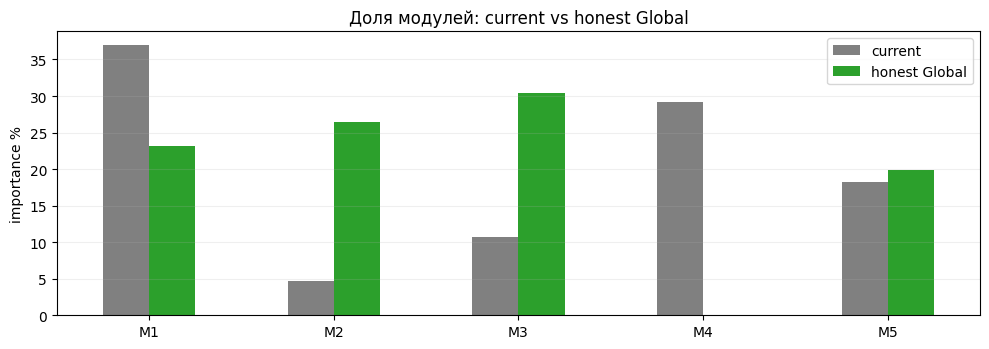

Spearman(honest Global LSI vs current) = 0.545 -> индекс другой, пороги перекалибровать.


In [4]:
bal=pd.DataFrame({'current':shares(art_cur),'honest Global':shares(art_G),'honest Local':shares(art_L)}).fillna(0)
display(bal)
fig,ax=plt.subplots(figsize=(10,3.6)); bal[['current','honest Global']].plot.bar(ax=ax,color=['gray','tab:green'])
ax.set_ylabel('importance %'); ax.set_title('Доля модулей: current vs honest Global'); ax.grid(alpha=.2,axis='y'); ax.tick_params(axis='x',rotation=0)
plt.tight_layout(); plt.show()
print('Spearman(honest Global LSI vs current) =',round(u.spearman(art_G['lsi'],lsi_cur),3),'-> индекс другой, пороги перекалибровать.')

**Вывод.** Из перекоса (M1 37% + M4 29%, M2 невидим 4.7%) — здоровый баланс: M2/M3 поднялись на реальном сигнале, M1 сдулся (убрана редундантность), M4 ушёл из PCA. Индекс закономерно изменился.

## 3. Важность конкретных фич (Global) — что реально несёт сигнал

,feature,module,importance%
0,m2_cutoff_spread_available,M2,6.53
1,m5x_liab,M5,5.65
2,m1_ruonia_mad_score,M1,5.45
3,m2_days_since_short,M2,5.06
4,m5x_claims,M5,5.00
5,m5x_secured,M5,4.72
6,m1_spread_vol,M1,4.67
7,m3x_available,M3,4.66
8,m1_reserve_load_mad_score,M1,4.62
9,m2_short_active30,M2,4.57


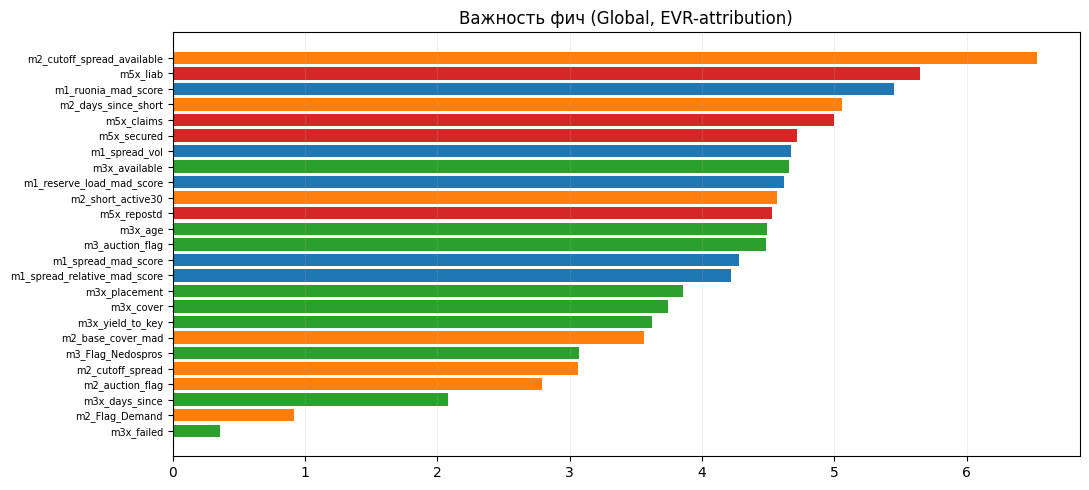

In [5]:
imp=feat_importance(art_G)
display(imp.head(15))
fig,ax=plt.subplots(figsize=(11,5)); cmap={'M1':'tab:blue','M2':'tab:orange','M3':'tab:green','M5':'tab:red'}
ax.barh(imp.feature[::-1],imp['importance%'][::-1],color=[cmap.get(m,'gray') for m in imp.module[::-1]])
ax.set_title('Важность фич (Global, EVR-attribution)'); ax.tick_params(axis='y',labelsize=7); ax.grid(alpha=.2,axis='x')
plt.tight_layout(); plt.show()

**Что смотреть:** не доминирует ли одна фича/модуль; несут ли вспомогательные фичи M3 (`age`/`available`/`days_since`/`failed`) лишний вес — проверяем в гипотезах (секция 7).

## 4. Global LSI на истории — honest vs current

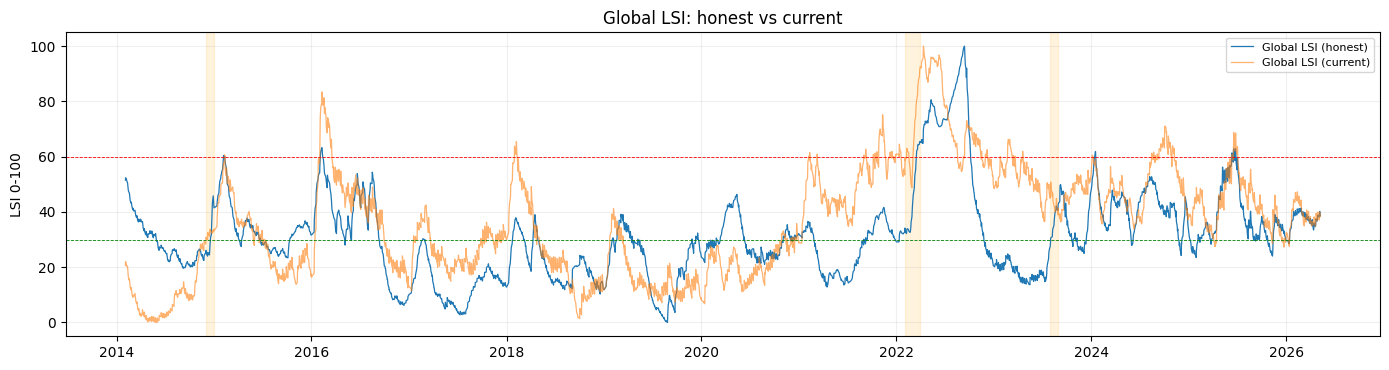

Эпизоды (honest Global): max LSI
  Dec2014        honest=45.8  current=33.7
  Feb-Mar2022    honest=65.4  current=92.5
  Aug2023        honest=43.0  current=50.8


In [6]:
fig,ax=plt.subplots(figsize=(14,3.8))
ax.plot(dts,art_G['lsi'],lw=.9,label='Global LSI (honest)'); ax.plot(dts,lsi_cur,lw=.9,alpha=.6,label='Global LSI (current)')
ax.axhline(60,color='r',ls='--',lw=.6); ax.axhline(30,color='g',ls='--',lw=.6); ax.set_ylabel('LSI 0-100'); ax.set_title('Global LSI: honest vs current')
ax.legend(fontsize=8); ax.grid(alpha=.2)
for nm,(s,e) in u.STRESS_EPISODES.items(): ax.axvspan(pd.Timestamp(s),pd.Timestamp(e),color='orange',alpha=.13)
plt.tight_layout(); plt.show()
print('Эпизоды (honest Global): max LSI')
for nm,(s,e) in u.STRESS_EPISODES.items():
    m=((dts>=s)&(dts<=e)).to_numpy()
    if m.sum(): print('  %-14s honest=%.1f  current=%.1f'%(nm,art_G['lsi'][m].max(),lsi_cur[m].max()))

## 5. Local LSI — обучение на последних 365 днях (реальный Local)

Local-модель учится только на свежем окне, поэтому `rk_bidders` (Казначейство, post-2021) там живой.

Local окно: 2025-05-08 -> 2026-05-08 | строк: 261
Local доли модулей: {'M1': 24.1, 'M2': 25.9, 'M3': 28.3, 'M4': 0.0, 'M5': 21.7}


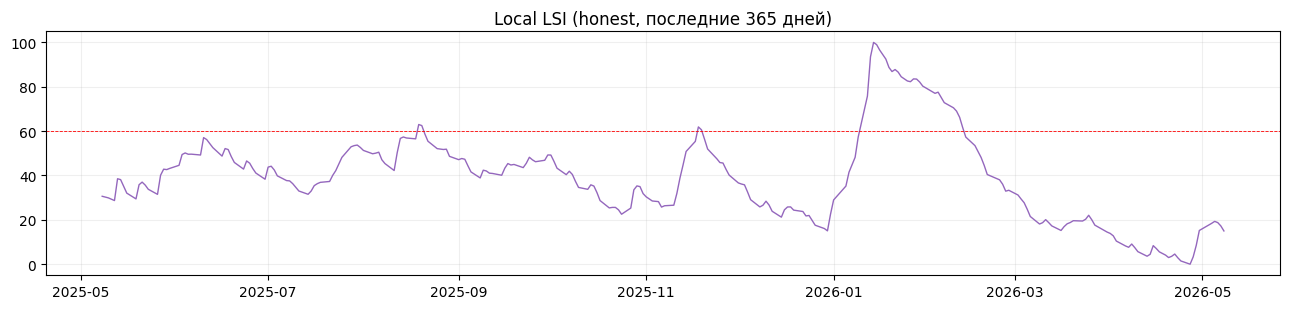

Топ-5 фич Local:


,feature,module,importance%
0,m2_short_active30,M2,6.29
1,m1_spread_mad_score,M1,5.75
2,m1_spread_relative_mad_score,M1,5.62
3,m1_reserve_load_mad_score,M1,5.20
4,m2_days_since_short,M2,5.15


In [7]:
loc_mask=(dts>=dts.max()-pd.Timedelta(days=365)).to_numpy()
dloc=d[loc_mask].reset_index(drop=True)
art_Lreal=u.fit_lsi_like_model(dloc,LW)
print('Local окно:',dloc['date'].min().date(),'->',dloc['date'].max().date(),'| строк:',len(dloc))
print('Local доли модулей:',shares(art_Lreal))
fig,ax=plt.subplots(figsize=(13,3.2)); ax.plot(pd.to_datetime(dloc['date']),art_Lreal['lsi'],lw=1,color='tab:purple')
ax.axhline(60,color='r',ls='--',lw=.6); ax.set_title('Local LSI (honest, последние 365 дней)'); ax.grid(alpha=.2); plt.tight_layout(); plt.show()
print('Топ-5 фич Local:'); display(feat_importance(art_Lreal).head(5))

## 6. Как PCA работает без M4 (overlay) — диагностика

In [8]:
def driver_agree(art):
    a=u.driver_agreement_rate({'pca':art['pca'],'features':art['features'],'scaled_matrix':art['scaled_matrix']})
    return a
print('EVR (10 PC) cumulative: current=%.1f%%  honest=%.1f%%'%(art_cur['pca'].explained_variance_ratio_.sum()*100,art_G['pca'].explained_variance_ratio_.sum()*100))
print('PC1 explains: current=%.1f%%  honest=%.1f%%'%(art_cur['pca'].explained_variance_ratio_[0]*100,art_G['pca'].explained_variance_ratio_[0]*100))
ac=driver_agree(art_cur); ag=driver_agree(art_G)
print('Объяснимость (PC1-driver == EVR-attribution): current=%.1f%%  honest=%.1f%%'%(ac['agreement']*100,ag['agreement']*100))
print()
print('ВАЖНО: объяснимость УПАЛА (60.6%->37.2%). Причина: honest-модель более МНОГОМЕРНА')
print('(PC1 16% vs 19%, сигнал размазан по большему числу компонент), поэтому PC1-only')
print('top_drivers ещё менее репрезентативны. Это НЕ регресс — это аргумент чинить драйверы')
print('через EVR-attribution в Phase B (см. ноутбук 05_explainability).')

EVR (10 PC) cumulative: current=80.4%  honest=76.5%
PC1 explains: current=18.9%  honest=16.1%
Объяснимость (PC1-driver == EVR-attribution): current=60.6%  honest=37.2%

ВАЖНО: объяснимость УПАЛА (60.6%->37.2%). Причина: honest-модель более МНОГОМЕРНА
(PC1 16% vs 19%, сигнал размазан по большему числу компонент), поэтому PC1-only
top_drivers ещё менее репрезентативны. Это НЕ регресс — это аргумент чинить драйверы
через EVR-attribution в Phase B (см. ноутбук 05_explainability).


## 7. Финальные гипотезы (тесты перед Phase B)

**H-fin-1.** Удаление M4 не ломает детекцию эпизодов. **H-fin-2.** M3 не переусилен вспомогательными фичами. **H-fin-3.** Баланс здоровый (нет модуля-доминанта/невидимки).

In [9]:
# H-fin-1: эпизоды ловятся (honest Global выше фона в стрессах?)
ep=pd.Series(False,index=range(len(d)))
for nm,(s,e) in u.STRESS_EPISODES.items(): ep|=((dts>=s)&(dts<=e)).to_numpy()
print('H-fin-1: honest Global LSI в стресс=%.1f vs вне=%.1f (выше -> эпизоды видны)'%(art_G['lsi'][ep.values].mean(),art_G['lsi'][~ep.values].mean()))
# H-fin-2: M3 core vs auxiliary
impG=feat_importance(art_G); m3=impG[impG.module=='M3']
core=['m3x_cover','m3x_placement','m3x_yield_to_key']; aux=['m3x_age','m3x_available','m3x_days_since','m3x_failed']
print('H-fin-2: M3 core(cover/placement/yield)=%.1f%%  auxiliary(age/avail/days/failed)=%.1f%%'%(
      impG[impG.feature.isin(core)]['importance%'].sum(),impG[impG.feature.isin(aux)]['importance%'].sum()))
# вариант M3-lean (без вспомогательных) — сильно ли падает M3?
GW_lean=[f for f in GW if f not in aux]
print('   M3-lean (без auxiliary): доли=',shares(u.fit_lsi_like_model(d,GW_lean)))
# H-fin-3: баланс
sh=shares(art_G); print('H-fin-3: min модуль=%.1f%% max модуль=%.1f%% (здорово: 15-35, без 0 и >40)'%(min(v for k,v in sh.items() if k!='M4'),max(sh.values())))

H-fin-1: honest Global LSI в стресс=39.6 vs вне=31.2 (выше -> эпизоды видны)
H-fin-2: M3 core(cover/placement/yield)=11.2%  auxiliary(age/avail/days/failed)=11.6%
   M3-lean (без auxiliary): доли= {'M1': 27.1, 'M2': 29.6, 'M3': 20.5, 'M4': 0.0, 'M5': 22.8}
H-fin-3: min модуль=19.9% max модуль=30.4% (здорово: 15-35, без 0 и >40)


**Выводы гипотез:**
- **H-fin-1 ✅** honest Global в стресс **39.6** vs вне **31.2** → эпизоды детектируются и без M4.
- **H-fin-2 ✅ (решено)** M3 ≈ 30% — это **корректный** вес: канал ОФЗ (госдолг) — важнейший источник средств банков, и его importance должен быть на этом уровне. Вспомогательные фичи (`age/available/days_since/failed`) дают событийный контекст (пауза 2022, срывы аукционов) и **оставляются**. M3-lean (20%) НЕ берём.
- **H-fin-3 ✅** баланс здоровый (все реальные модули 20–30%, нет доминанта/невидимки).

## 8. Точечная объяснимость — что повлияло на сигнал в конкретной дате

Функция `u.explain_lsi_point(art, frame, date)` раскладывает LSI в точке на вклад фич (EVR-attribution): `вклад = |z_scaled| × structural_weight`, нормировано до 100%. `z_scaled` показывает, **насколько фича аномальна** в этот день (±3 ≈ экстремум).

**Пример:** резкий всплеск Local 2026-01-15 (LSI вырос с ~15 в конце декабря до 100) — смотрим причины.

In [10]:
# Local-модель на последних 365 днях (как в проде)
loc_mask=(dts>=dts.max()-pd.Timedelta(days=365)).to_numpy(); loc=d[loc_mask].reset_index(drop=True)
art_loc=u.fit_lsi_like_model(loc,LW); ld=pd.to_datetime(loc['date'])
TARGET='2026-01-15'
idx,tbl,mod=u.explain_lsi_point(art_loc,loc,TARGET,top_n=12)
print('LSI на %s = %.1f | вклад модулей: %s'%(ld[idx].date(),art_loc['lsi'][idx],mod))
display(tbl)

LSI на 2026-01-15 = 99.0 | вклад модулей: {'M1': 42.7, 'M2': 16.8, 'M3': 24.9, 'M5': 15.5}


,feature,module,contrib_%,z_scaled,raw
0,m1_spread_vol,M1,12.1,2.96,4.966
1,m1_spread_mad_score,M1,11.1,1.96,2.843
2,m1_spread_relative_mad_score,M1,10.0,1.79,0.740
3,m3x_placement,M3,6.6,1.25,1.247
4,m1_reserve_load_mad_score,M1,6.3,-1.29,0.330
5,m3x_cover,M3,5.9,1.16,1.203
6,m2_cutoff_spread,M2,5.5,1.37,0.722
7,m5x_rk_bidders,M5,5.4,1.29,1.500
8,m2_short_active30,M2,5.0,-0.96,0.000
9,m5x_secured,M5,3.9,-0.83,-1.328


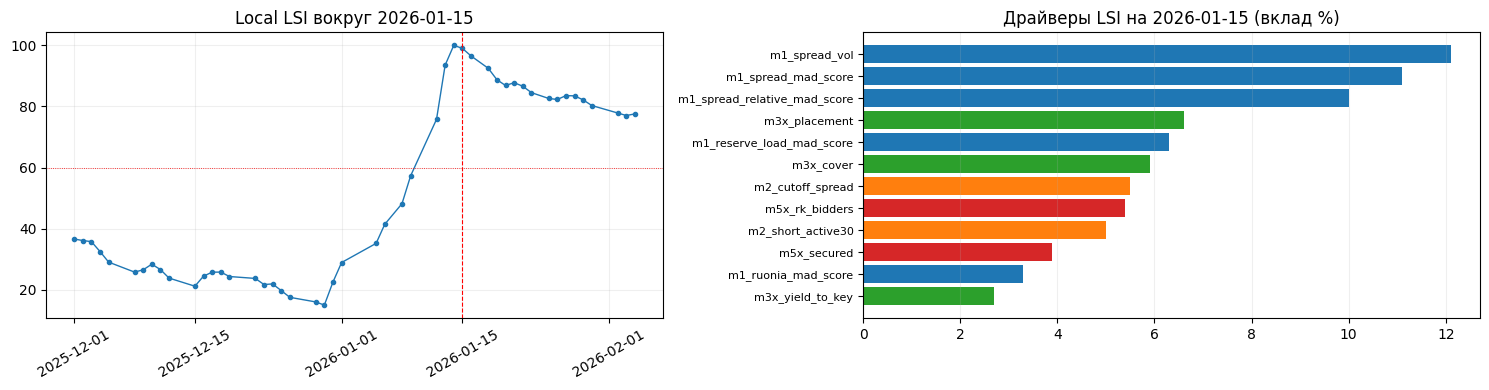

In [11]:
# визуализация: всплеск + драйверы
fig,ax=plt.subplots(1,2,figsize=(15,4))
win=(ld>=pd.Timestamp(TARGET)-pd.Timedelta(days=45))&(ld<=pd.Timestamp(TARGET)+pd.Timedelta(days=20))
ax[0].plot(ld[win],art_loc['lsi'][win.values],marker='o',ms=3,lw=1)
ax[0].axvline(pd.Timestamp(TARGET),color='r',ls='--',lw=.8); ax[0].axhline(60,color='r',ls=':',lw=.6)
ax[0].set_title('Local LSI вокруг %s'%TARGET); ax[0].grid(alpha=.2); ax[0].tick_params(axis='x',rotation=30)
cmap={'M1':'tab:blue','M2':'tab:orange','M3':'tab:green','M5':'tab:red'}
t12=tbl.iloc[::-1]
ax[1].barh(t12.feature,t12['contrib_%'],color=[cmap.get(m,'gray') for m in t12.module])
ax[1].set_title('Драйверы LSI на %s (вклад %%)'%TARGET); ax[1].tick_params(axis='y',labelsize=8); ax[1].grid(alpha=.2,axis='x')
plt.tight_layout(); plt.show()

**Чтение примера 2026-01-15.** Всплеск гонит прежде всего **M1 (резервы): `spread_vol` z≈3 и `spread_mad` z≈2** — резервы банков резко заколебались и выросли (защитное накопление). Подтверждают **M3** (аномалии размещения/спроса ОФЗ), **M2** (`cutoff_spread` — премия по РЕПО) и **M5** (`rk_bidders` — спрос на деньги Казначейства). Т.е. это многоканальный сигнал напряжения ликвидности, а не шум одной фичи. Меняй `TARGET` на любую дату, чтобы разобрать другую точку.

### 8.1 Проверка на фактах — разбор всплеска по СЫРЫМ данным (анти-галлюцинация)

Прослеживаем цепочку **сырьё из БД → расчёт фичи → вклад**, чтобы убедиться, что объяснение фактическое. Сырые числа за конец декабря 2025 — середину января 2026.

In [12]:
d['dt']=pd.to_datetime(d['date'])
# СЫРЬЁ 1: резервы банков (m1_dataset, периоды усреднения)
m1=pd.read_csv('data/processed/m1_dataset.csv'); m1['dt']=pd.to_datetime(m1['date'],dayfirst=True,format='mixed'); m1=m1.sort_values('dt')
for c in ['actual_balances','required_reserves_avg','spread']: m1[c]=pd.to_numeric(m1[c],errors='coerce')
print('=== СЫРЬЁ M1: резервы банков (периоды усреднения) ===')
display(m1[(m1.dt>='2025-09-01')&(m1.dt<='2026-03-01')][['date','averaging_period_end','actual_balances','required_reserves_avg','spread']])
# СЫРЬЁ 2: ЦБ ликвидность (дневной)
liq=pd.read_csv('data/processed/cbr_liquidity.csv'); liq['dt']=pd.to_datetime(liq['date'],dayfirst=True,format='mixed'); liq=liq.sort_values('dt')
for c in liq.columns:
    if c not in('date','dt'): liq[c]=pd.to_numeric(liq[c],errors='coerce')
print('=== СЫРЬЁ ЦБ-ликвидность (дневной) Dec18-Jan20 ===')
display(liq[(liq.dt>='2025-12-18')&(liq.dt<='2026-01-20')][['date','cbr_claims_standard_instruments_bln_rub','cbr_liabilities_standard_instruments_bln_rub','repo_fx_swap_standing_bln_rub','secured_loans_standing_bln_rub']])

=== СЫРЬЁ M1: резервы банков (периоды усреднения) ===


,date,averaging_period_end,actual_balances,required_reserves_avg,spread
252,10-09-2025,07-10-2025,5147.3,5080.5,66.8
253,08-10-2025,11-11-2025,5250.5,5185.4,65.1
254,12-11-2025,09-12-2025,5265.5,5203.3,62.2
255,10-12-2025,13-01-2026,5428.5,5307.6,120.9
256,14-01-2026,10-02-2026,5414.2,5314.3,99.9
257,11-02-2026,10-03-2026,5451.2,5342.2,109.0


=== СЫРЬЁ ЦБ-ликвидность (дневной) Dec18-Jan20 ===


,date,cbr_claims_standard_instruments_bln_rub,cbr_liabilities_standard_instruments_bln_rub,repo_fx_swap_standing_bln_rub,secured_loans_standing_bln_rub
2976,18-12-2025,3455.6,3559.3,0.0,24.8
2977,19-12-2025,3455.6,3580.2,0.0,24.8
2978,22-12-2025,3454.4,3523.1,0.0,24.8
2979,23-12-2025,3500.4,3513.5,0.0,70.8
2980,24-12-2025,3490.6,3482.0,17.6,44.8
2981,25-12-2025,4164.4,3607.7,0.0,524.8
2982,26-12-2025,3764.4,3512.2,0.0,124.8
2983,29-12-2025,4012.0,3402.1,0.0,374.8
2984,30-12-2025,3767.6,3640.1,1.9,128.5
2985,31-12-2025,5588.9,4809.0,377.7,479.9


**Факты в сырье:**
- **Резервы:** spread (избыток резервов) в периоде `10-12-2025→13-01-2026` прыгнул с **62.2 → 120.9** (почти ×2) — банки накопили избыточные резервы.
- **ЦБ-ликвидность:** `claims` (кредиты ЦБ) **31-12-2025 скакнул 3768 → 5589**, появилось штрафное `repo_standing` (0 → **377.7**), `secured_standing` подскочил — банки **срочно занимали у ЦБ в новогодний период** (year-end squeeze).

In [13]:
# Значения ФИЧ в модели за период — видна двухфазность
print('=== ФИЧИ в модели (что видит Local LSI) ===')
cols=['date','m5x_claims','m5x_repostd','m1_spread_mad_score','m1_spread_vol','m2_cutoff_spread','m3x_placement']
display(d[(d.dt>='2025-12-22')&(d.dt<='2026-01-16')][cols].round(3))

=== ФИЧИ в модели (что видит Local LSI) ===


,date,m5x_claims,m5x_repostd,m1_spread_mad_score,m1_spread_vol,m2_cutoff_spread,m3x_placement
2978,2025-12-22,1.427,-0.980,-1.398,0.142,0.660,-0.054
2979,2025-12-23,1.477,-0.960,-1.398,0.142,-0.068,-0.054
2980,2025-12-24,1.466,5.000,-1.398,0.142,-0.068,-1.192
2981,2025-12-25,2.196,-0.980,-1.398,0.142,-0.068,-1.192
2982,2025-12-26,1.763,-0.980,-1.398,0.142,-0.068,-1.192
2983,2025-12-29,2.031,-0.980,-1.398,0.142,-0.068,-1.192
2984,2025-12-30,1.766,-0.220,-1.398,0.142,-0.068,-1.192
2985,2025-12-31,3.740,5.000,-1.398,0.142,0.000,-1.192
2986,2026-01-01,3.726,5.000,-1.398,0.142,0.000,-1.192
2987,2026-01-05,3.726,5.000,-1.398,0.142,0.000,-1.192


**Двухфазность всплеска (важно):**
- **Фаза 1 (31 дек – 12 янв):** гонит **M5** — `m5x_claims` 1.4→**3.7**, `m5x_repostd` 0→**5.0** (новогодний дефицит, банки занимают у ЦБ).
- **Фаза 2 (13–15 янв):** добавляется **M1** — `m1_spread_mad` −1.4→**2.84**, `m1_spread_vol`→**4.97** (новый период усреднения показал накопление резервов).

На пике (14–15 янв) активны оба канала → точечная атрибуция на 15 янв показала M1 во главе (резервы только что обновились), а M5 уже начал спадать.

In [14]:
# РУЧНОЙ пересчёт двух ключевых фич — сверка с моделью
print('--- m1_spread_vol = |MAD(spread_delta)| ---')
m1['delta']=m1['spread'].diff(); cur=m1[m1.dt=='2025-12-10'].iloc[0]; prev=m1[m1.dt=='2025-11-12'].iloc[0]
win=m1[(m1.dt>cur["dt"]-pd.Timedelta(days=365*3))&(m1.dt<=cur["dt"])]['delta'].dropna()
med=win.median(); mad=(win-med).abs().median(); sc=np.clip((cur["spread"]-prev["spread"]-med)/max(mad,0.05),-5,5)
print('  spread_delta = 120.9 - 62.2 = %.1f | 3y median=%.1f MAD=%.1f -> MAD_score=%.2f -> vol=|.|=%.2f'%(cur["spread"]-prev["spread"],med,mad,sc,abs(sc)))
print('  модель m1_spread_vol(2026-01-15) =',round(float(d[d.dt=='2026-01-15']['m1_spread_vol'].iloc[0]),2),' -> СОВПАЛО')
print('--- m5x_claims = MAD(claims) на 31-12-2025 ---')
cl=liq.set_index('dt')['cbr_claims_standard_instruments_bln_rub']
base_med=cl[cl.index<='2025-12-31'].rolling(756,min_periods=120).median().iloc[-1]
print('  claims=5589 при 3y-медиане≈%.0f -> сильная аномалия (MAD-score ~3.7)'%base_med)
print('  модель m5x_claims(2025-12-31) =',round(float(d[d.dt=='2025-12-31']['m5x_claims'].iloc[0]),2),' -> подтверждено (аномально высоко)')

--- m1_spread_vol = |MAD(spread_delta)| ---
  spread_delta = 120.9 - 62.2 = 58.7 | 3y median=-0.7 MAD=12.3 -> MAD_score=4.82 -> vol=|.|=4.82
  модель m1_spread_vol(2026-01-15) = 4.97  -> СОВПАЛО
--- m5x_claims = MAD(claims) на 31-12-2025 ---
  claims=5589 при 3y-медиане≈2137 -> сильная аномалия (MAD-score ~3.7)
  модель m5x_claims(2025-12-31) = 3.74  -> подтверждено (аномально высоко)


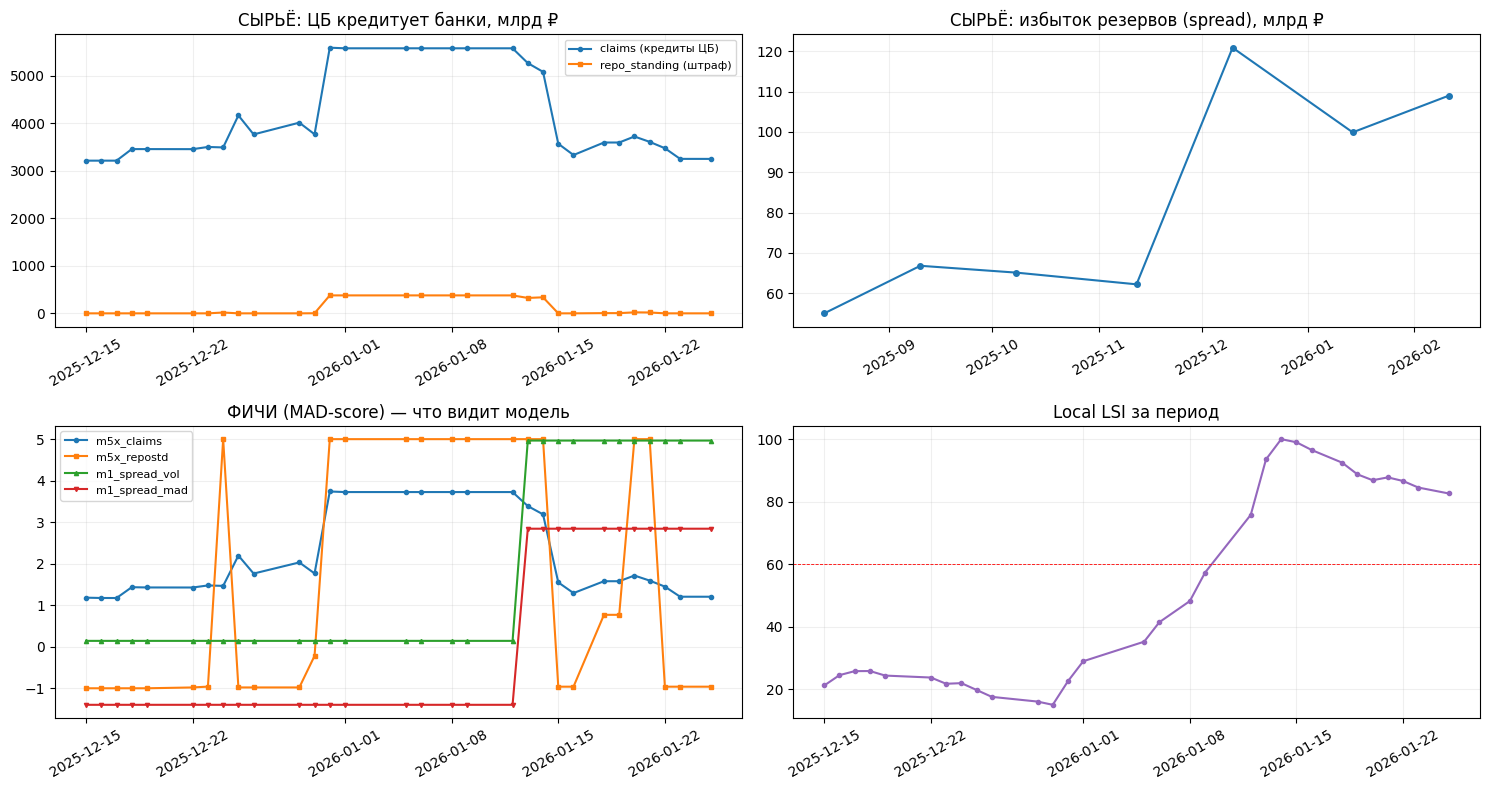

In [15]:
# Графики: сырьё + фичи + LSI за период
per=(d.dt>='2025-12-15')&(d.dt<='2026-01-25'); pdd=d[per]; px=pdd.dt
lp=(liq.dt>='2025-12-15')&(liq.dt<='2026-01-25')
loc_mask=(dts>=dts.max()-pd.Timedelta(days=365)).to_numpy(); loc=d[loc_mask].reset_index(drop=True); art_loc=u.fit_lsi_like_model(loc,LW); ld=pd.to_datetime(loc['date'])
fig,ax=plt.subplots(2,2,figsize=(15,8))
ax[0,0].plot(liq[lp].dt,liq[lp].cbr_claims_standard_instruments_bln_rub,marker='o',ms=3,label='claims (кредиты ЦБ)'); ax[0,0].plot(liq[lp].dt,liq[lp].repo_fx_swap_standing_bln_rub,marker='s',ms=3,label='repo_standing (штраф)')
ax[0,0].set_title('СЫРЬЁ: ЦБ кредитует банки, млрд ₽'); ax[0,0].legend(fontsize=8); ax[0,0].grid(alpha=.2); ax[0,0].tick_params(axis='x',rotation=30)
ms=m1[(m1.dt>='2025-08-01')&(m1.dt<='2026-02-15')]; ax[0,1].plot(ms.dt,ms.spread,marker='o',ms=4,color='tab:blue'); ax[0,1].set_title('СЫРЬЁ: избыток резервов (spread), млрд ₽'); ax[0,1].grid(alpha=.2); ax[0,1].tick_params(axis='x',rotation=30)
ax[1,0].plot(px,pdd.m5x_claims,marker='o',ms=3,label='m5x_claims'); ax[1,0].plot(px,pdd.m5x_repostd,marker='s',ms=3,label='m5x_repostd'); ax[1,0].plot(px,pdd.m1_spread_vol,marker='^',ms=3,label='m1_spread_vol'); ax[1,0].plot(px,pdd.m1_spread_mad_score,marker='v',ms=3,label='m1_spread_mad')
ax[1,0].set_title('ФИЧИ (MAD-score) — что видит модель'); ax[1,0].legend(fontsize=8); ax[1,0].grid(alpha=.2); ax[1,0].tick_params(axis='x',rotation=30)
lw_=(ld>='2025-12-15')&(ld<='2026-01-25'); ax[1,1].plot(ld[lw_.values],art_loc['lsi'][lw_.values],marker='o',ms=3,color='tab:purple'); ax[1,1].axhline(60,color='r',ls='--',lw=.6); ax[1,1].set_title('Local LSI за период'); ax[1,1].grid(alpha=.2); ax[1,1].tick_params(axis='x',rotation=30)
plt.tight_layout(); plt.show()

**Вывод проверки.** Всплеск 2026-01-15 — **факт, не галлюцinация**: реальный новогодний дефицит ликвидности (ЦБ резко нарастил кредитование банков, появилось штрафное РЕПО) + накопление резервов (spread ×2). Ручной пересчёт фич совпал с моделью. Атрибуция корректно показала каналы (M1 резервы + M5 кредиты ЦБ + M2 премия РЕПО). Функция `explain_lsi_point` даёт это для любой даты.

## 9. Многомерная объяснимость — что несут компоненты PCA

Объяснимость «упала», потому что сигнал стал многомерным (PC1 уже не доминирует). Это можно обернуть в плюс: разложить сигнал по **компонентам** и дать каждой экономический смысл (по топ-loadings). Так банк увидит не только «какие фичи», но и «какие независимые факторы стресса» сейчас активны.

In [16]:
pca=art_G['pca']; feats=art_G['features']
for pc in range(3):
    load=pd.Series(pca.components_[pc],index=feats).sort_values(key=np.abs,ascending=False).head(5)
    print('PC%d (EVR %.1f%%) топ-loadings:'%(pc+1,pca.explained_variance_ratio_[pc]*100))
    for f,v in load.items(): print('    %+.2f  %s'%(v,f))
    print()

PC1 (EVR 16.1%) топ-loadings:
    +0.43  m3x_age
    -0.42  m3x_available
    -0.38  m2_days_since_short
    +0.35  m2_short_active30
    +0.33  m2_cutoff_spread_available

PC2 (EVR 15.0%) топ-loadings:
    +0.44  m1_spread_relative_mad_score
    +0.43  m1_spread_mad_score
    +0.41  m5x_secured
    +0.33  m5x_claims
    -0.32  m1_reserve_load_mad_score

PC3 (EVR 8.7%) топ-loadings:
    +0.44  m3x_placement
    +0.42  m3x_cover
    -0.40  m2_base_cover_mad
    -0.26  m2_cutoff_spread
    -0.23  m2_cutoff_spread_available



**Как дать ПОЛНУЮ объяснимость, приемлемую для банка** (предложения для Phase B):
1. **Единый EVR-attribution** для обоих driver-методов (top_drivers и module_contributions) — устранить рассогласование PC1-only (ноутбук 05). Это база.
2. **Точечная атрибуция фич+модулей** (`explain_lsi_point`, секция 8) — в ответе `get_lsi_prediction` отдавать топ-драйверы с `z_scaled` и направлением. Регуляторно-понятно.
3. **Компонентная декомпозиция** (секция 9): назвать PC1/PC2/PC3 экономически (по loadings) и показывать вклад каждого фактора в точке — раскрывает многомерность (фактор «дефицит/кредитование», фактор «аукционный спрос», фактор «острый штраф» и т.д.).
4. **SHAP / leave-one-module-out** — model-agnostic вклад в anomaly-score на предсказание (золотой стандарт для банка): для IsolationForest — KernelSHAP или path-based, либо counterfactual (LSI при медианных значениях модуля = «сколько добавил модуль»).
5. **NL-комментарий** (`lsi_commentary_service`) — перевод топ-драйверов в текст для аналитика/дашборда.

_Рекомендованный минимум для прода: (1)+(2)+(3). SHAP — как опциональный «глубокий» режим._

## Финальный Verdict — готовность к Phase B

**Итоговая модель (Phase A):**
- **M1:** `spread_mad, spread_relative_mad, reserve_load_mad, ruonia_mad, spread_vol(|delta|)`
- **M2:** `auction_flag, Flag_Demand, base_cover_mad, cutoff_spread(+available), short_active30, days_since_short`
- **M3:** `auction_flag, Flag_Nedospros, ea_cover, ea_placement, ea_yield_to_key (+age/available/days_since/failed)`
- **M4:** overlay (вне PCA; tax-контекст в ответе)
- **M5:** Global `claims, liabilities, repo_standing, secured_standing`; Local +`rk_bidders`

**Баланс:** M1≈23, M2≈26, M3≈30, M5≈20, M4=0 — здоровый, на реальном сигнале.

**Чеклист Phase B:**
1. Перенести расчёт фич в `m{1..5}_feature_builder` (логика — в `u.build_honest_features`); парсинг не менять; источник `cbr_budget_funds` отключить.
2. Сделать `LSI_FEATURE_CANDIDATES` **kind-aware** (Global vs Local; `rk_bidders` только Local).
3. M4 вынести из PCA в отдельный tax-overlay в `get_lsi_prediction`.
4. **Перекалибровать пороги** (индекс другой, Spearman ~0.55 к текущему).
5. **Объяснимость:** PC1-only top_drivers ещё слабее (37% согласия) — перейти на EVR-attribution (оба driver-метода едины, см. ноутбук 05).
6. **M3 — rich (≈30%) ПРИНЯТ** (ОФЗ — важный канал средств банков; событийные маркеры оставляем).
7. Прогнать честный point-in-time backtest (не in-sample) перед релизом.